# Lab 3: Visualizations
**Author:** 
**Date:** 2026-04-13

___

#### Topic Outline:

- Visualizations in `python` using `matplotlib.pyplot` and `seaborn`.
- Advantages and disadvantages of each library.
- Basic plots and their uses:
  - Line plots.
  - Scatter plots.
  - Bar plots.
  - Histograms.

---

#### Collaboration

You are encouraged to collaborate with other students in your labs, but you are expected to write up your own work for submission.  Please do not copy and paste other people's solutions to problems as it is considered plagiarism and you will be penalized and reported.  Should you choose to collaborate with others, please note their names here:

**Your name:** 

**Collaborators:**

1.

___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your lab assignments and to enhance your learning experience.  Please make a note of any agents you have used in this submission here:

**Agents:** 

---

## Introduction

An key part of data analysis is visualization, producing plots that help summarize and describe the properties and relationships of a data set.  In `python` we have many libraries for producing visualizations, for example `matplotlib`, `seaborn` and `altair`, each of which come with their advantages and disadvantages.  In this lab we will be looking at some of the most important and widely used visualization, what they are used for, and how they are produced in each package.

In the next chunk we load the required data packages:

In [3]:
# Libraries
!pip install numpy pandas matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.9 MB/s eta 0:00:00
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 58.9 MB/s eta 0:00:0000:0100:01
   ━

Remember to install these packages using `pip install` if you have never used these in your python environment before (e.g. if you have started a new virtual environment).

---

## 1. `matplotlib.pyplot` vs `seaborn` vs `altair`

Two of the most widely used plotting packages in `python` are `matplotlib.pyplot` and `seaborn`.  

### 1.1. `matplotlib.pyplot`

`matplotlib.pyplot` is the foundational visualization library in Python. It provides a MATLAB-style interface for building static, publication-quality figures. Almost every other Python visualization library — including `seaborn` — is built on top of it, making it essential to understand even if you often work at a higher level of abstraction.  It is imperative, meaning that we specify every detail of the graph, giving maximum control at the cost of verbose syntax.  This control makes it the default choice for producing publication quality static outputs which often are heavily customized and created to maximize clarity of a certain niche point.

### 1.2. `seaborn`

`seaborn` is built on top of `matplotlib` and provides a higher-level, more declarative interface.  This means that with `seaborn` it is quite easy to create complicated visualizations quickly with the added benefit of being able to tweak the outputs using `matplotlib.pyplot` syntax.  This is the typical go to for producing quite visualizations for data exploration, sacrifising the pure customization of `matplotlib.pyplot` for efficiency.

### 1.3. `altair`

`altair` is the most declarative of the three allowing users to declar how the data should be displayed with the library automatically taking care of the presentation.  It also ships with more built in interactivity and statistical features than either `matplotlib` or `seaborn`, for example distribution plots, regression lines etc.

> **Note:** We will not cover the use of `altair` in this workshop due to time but will cover in when needed during lecture and in future labs and assignments.

---

## 2. Bar Charts

We begin with **bar charts** which are used to show the distribution and relationships between categorical data (i.e. variables labelling observations).  We will use several famous data visualization data sets throughout this lab, starting with the Titanic data set which is a collection of synthetic variables for passengers on the titanic.

In [5]:
# Load titanic dataset
titanic = pd.read_csv("data/titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We start by producing a simple bar chart highlighting the survival rate of passengers using the `plt.bar` function from `matplotlib.pyplot`.  The function requires us to input count data (i.e. a dataframe with count values for the height of each bar).  We begin by relabelling the variable `Survived` using a mapping (see previous lab) before computing the `survival_counts` data frame:

In [6]:
# Relabel the "Survived" column for better readability
titanic["Survived"] = titanic["Survived"].map({0: "Did Not Survive", 1: "Survived"})
# Compute survival counts
survival_counts = titanic["Survived"].value_counts()
print(survival_counts)

Survived
Did Not Survive    549
Survived           342
Name: count, dtype: int64


We can then produce a simple bar plot using the function `plt.bar`.  We also call `plt.show()` which shows the plot we have created:

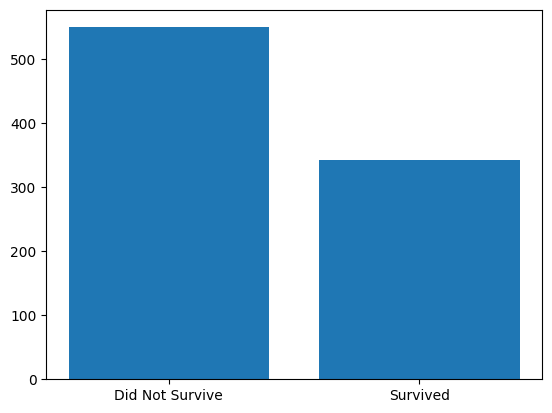

In [7]:
plt.bar(
    survival_counts.index,   # x axis categories 
    survival_counts.values  # corresponding y axis counts
)
plt.show()

Here we have employed **state-oriented approach** `plt.plot(object)` but typically in python it is preferable to use an **object-oriented approach** `object.plot()`.  This preference is both due to the fragility of state-oriented approaches (e.g. axes can change dependent on cell execution order) but also to help with the syntax for multi-plots which we will cover in lecture.  The equivalent object-oriented syntax for this plot is: 

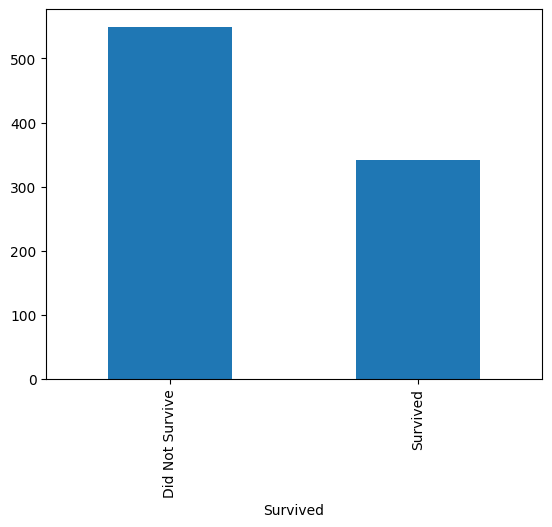

In [8]:
survival_counts.plot(
    kind="bar",              # specify bar plot
)
plt.show()

There are a collection of functions we can use to **format plots** in `matplotlib.pyplot` including changing the bar color and outline, changing figure size, axis labels and titles.  We add all of these formatting options in the chunk below with a `python` comment explaining the change it is repsonsible for:

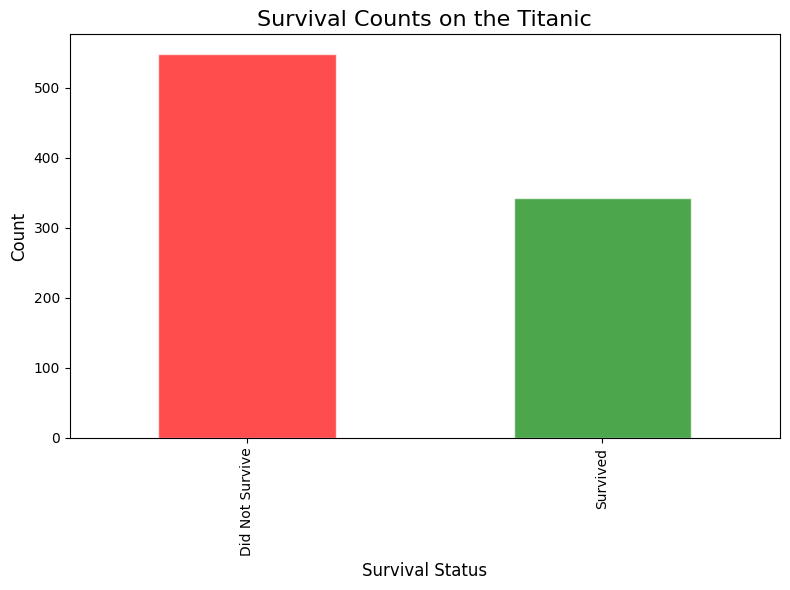

In [9]:
plt.figure(figsize=(8, 6))   # set figure size for better visibility
survival_counts.plot(
    kind="bar",              # specify bar plot
    color=["red", "green"],   # custom colors for bars
    edgecolor="white",        # add white outline to bars
    alpha=0.7                 # set transparency for bars
)
plt.title("Survival Counts on the Titanic", fontsize=16)
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()  # adjust layout to prevent overlap
plt.show()

Suppose we would like to subgroup each of these bars by sex.  This is reasonably simple in python and just requires us to change our input dataframe to also incorporate this subgrouping:

In [7]:
# Subgrouping by sex
survival_by_sex = titanic.groupby("Survived")["Sex"].value_counts().unstack()
print(survival_by_sex)      

Sex              female  male
Survived                     
Did Not Survive      81   468
Survived            233   109


Then using the same syntax as before with the addition of a legend we obtain:

<Figure size 800x600 with 0 Axes>

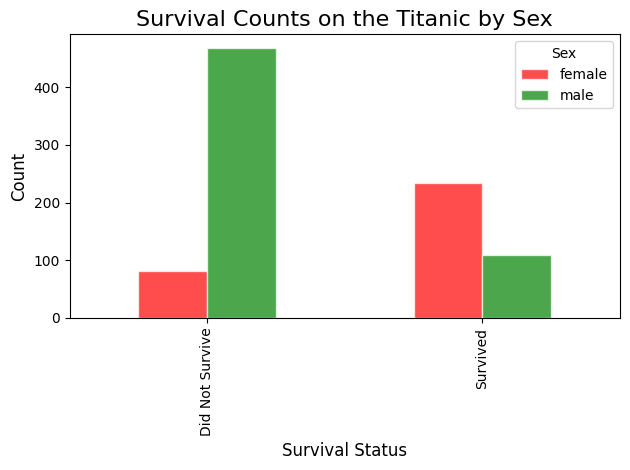

In [8]:
# Bar plot with subgrouping by sex
plt.figure(figsize=(8, 6))
survival_by_sex.plot(kind="bar", color=["red", "green"], edgecolor="white", alpha=0.7)
plt.title("Survival Counts on the Titanic by Sex", fontsize=16)
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q1 Bar Charts

Using the example code above make a bar chart displaying the survival status grouped by passenger class (the `pClass` variable).  Change your formatting to your preferred style.  Research how to produce stacked bar charts and also horizontal bar charts and add these formatting preferences.

___

**Solution:**

Pclass             1   2    3
Survived                     
Did Not Survive   80  97  372
Survived         136  87  119


<Figure size 800x600 with 0 Axes>

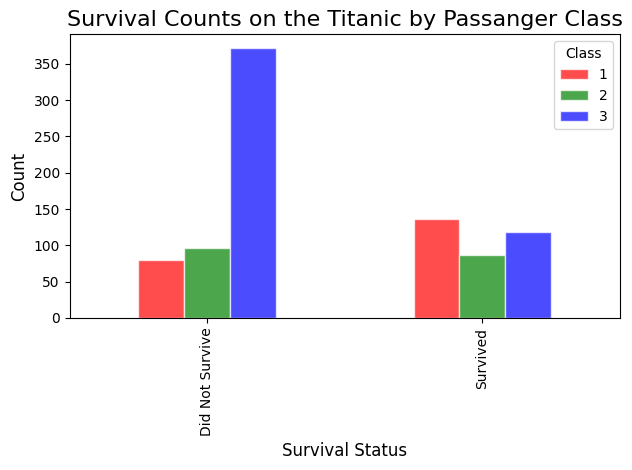

In [19]:
survival_by_passanger = titanic.groupby("Survived")["Pclass"].value_counts().unstack()
print(survival_by_passanger)

plt.figure(figsize=(8,6))
survival_by_passanger.plot(kind="bar", color=["red", "green", "blue"], edgecolor="white", alpha=0.7)
plt.title("Survival Counts on the Titanic by Passanger Class", fontsize=16)
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Class")
plt.tight_layout()
plt.show()


---

## 2. Line Plots

### 2.1. Line plots in `matplotlib`

A **line plot** is used to visualize ordinal numerical data, for example time series data (e.g. stock prices) to visualize change over time.  For the following section we begin by generating some synthetic example data to produce lines corresponding to the functions:

$$
\begin{aligned}
f(x) & = \frac{1}{100} (2x^3 + 7) \\
g(x) & = \frac{1}{10} (x^2 + 3x - 2),
\end{aligned}
$$

for $x\in[-10, 10]$.  Since we can't create continuous lines we discretize this interval using `np.linspace`:

In [10]:
# Generate synthetic data frame
x = np.linspace(-10, 10, 100)
f = (2 * x ** 3 + 7)/100
g = (x ** 2 + 3 * x - 2)/10
line_plot_data = pd.DataFrame({"x": x, "f": f, "g": g})
line_plot_data.head()

,x,f,g
0,-10.000000,-19.930000,6.800000
1,-9.797980,-18.742201,6.460647
2,-9.595960,-17.602388,6.129456
3,-9.393939,-16.509570,5.806428
4,-9.191919,-15.462758,5.491562


To produce a simple plot for f we once again use the object-oriented approach:

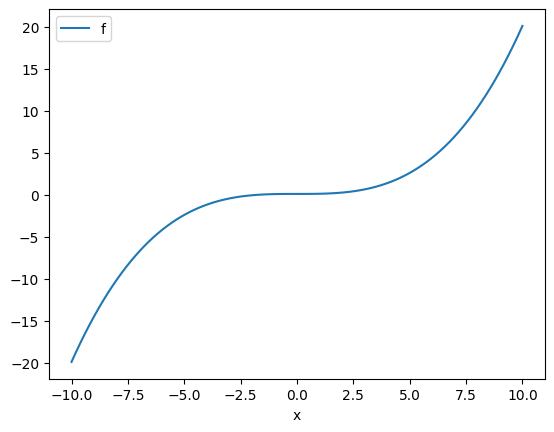

In [11]:
# Simple line plot
line_plot_data.plot(
    x="x",            # specify x axis variable
    y=["f"],          # specify y axis variable(s)
    kind="line"       # specify we would like a line plot
    )   
plt.show()                     # show the plot

Let's once again change the plot formatting using all of the same functions as for our bar chart but this time with some new arguments to format our line:

<Figure size 1000x500 with 0 Axes>

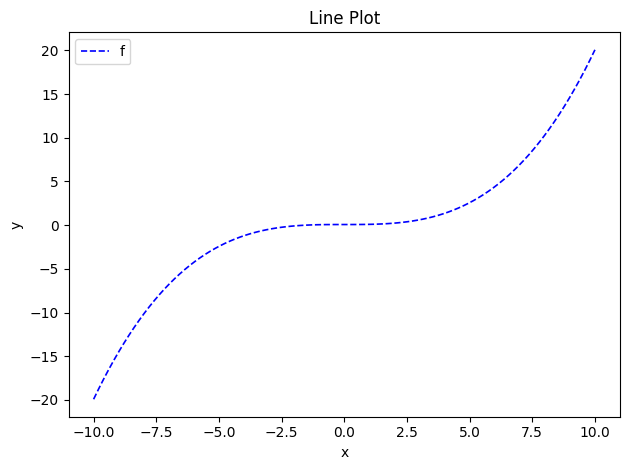

In [12]:
plt.figure(figsize=(10, 5)) # set the figure size
line_plot_data.plot(
    x="x",            # specify x axis variable
    y=["f"],     # specify y axis variable(s)
    kind="line",       # specify we would like a line plot
    color="blue",      # set line color to blue
    linestyle="--",    # set line style to dashed
    linewidth=1.2        # set line width to 1.2
    )    
plt.title("Line Plot")      # set the title
plt.xlabel("x")             # set the x-axis label
plt.ylabel("y")      # set the y-axis label
plt.tight_layout()          # adjust the layout to use space efficiently
plt.show()                  

We can also add multiple lines to our plot but at this point we start to run into the limitations of this `syntax`.

<Figure size 1000x500 with 0 Axes>

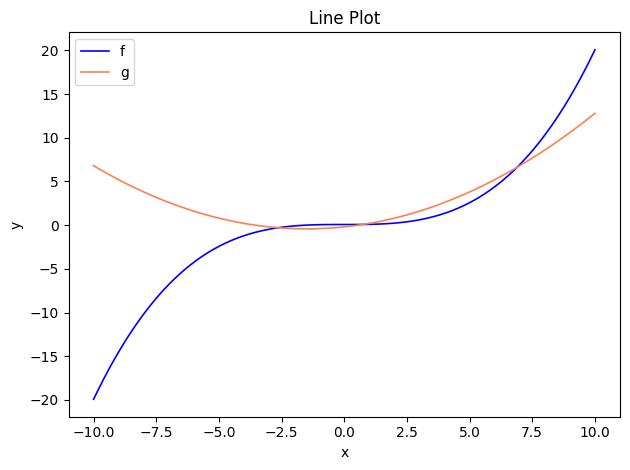

In [13]:
plt.figure(figsize=(10, 5)) # set the figure size
line_plot_data.plot(
    x="x",            # specify x axis variable
    y=["f", "g"],     # specify y axis variable(s)
    kind="line",       # specify we would like a line plot
    color=["blue", "coral"],      # set line color to blue
    linestyle="-",    # set line style to dashed
    linewidth=1.2        # set line width to 1.2
    )
plt.title("Line Plot")      # set the title
plt.xlabel("x")             # set the x-axis label
plt.ylabel("y")          # set the y-axis label
plt.legend()                # show the legend
plt.tight_layout()          # adjust the layout
plt.show()                  # show the plot

Although we can specify different line colors, if we want to specify different line types we would have to resort back to a state orientated approach and call multiple `plt.plot()` outputs.  This dramatically increases our syntax verbosity and so instead we look at using `seaborn` functions instead.  

### 2.2. Line plots in `seaborn`

Plotting in `seaborn` can be compared broadly to using `ggplot` in `R`.  We load data into the plotting function in long format and then specify formatting based on specific variables.  Recall that we can use the `melt` function to convert to long format:

In [14]:
# Convert data to long format for seaborn
line_plot_long = line_plot_data.melt(id_vars="x", value_vars=["f", "g"], var_name="Function", value_name="Value")
line_plot_long.head()

,x,Function,Value
0,-10.000000,f,-19.930000
1,-9.797980,f,-18.742201
2,-9.595960,f,-17.602388
3,-9.393939,f,-16.509570
4,-9.191919,f,-15.462758


We can then use this transformed data set to produce our line plot as follows:

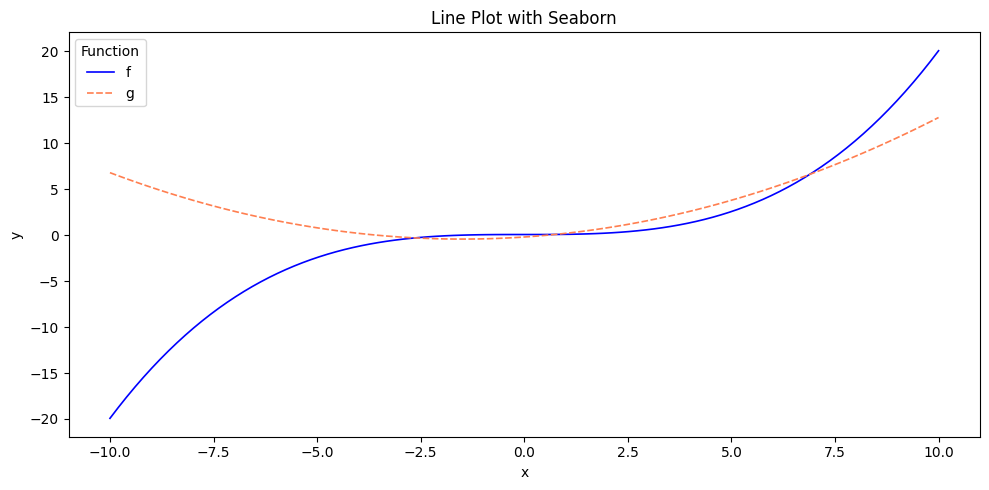

In [14]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=line_plot_long,          # data in long format
    x="x",                        # variable for the x-axis
    y="Value",                    # variable for the y-axis
    hue="Function",               # different colors for each function
    style="Function",             # different line types for each function
    linewidth=1.2,                # make the lines thicker
    palette={"f": "blue", "g": "coral"}  # set custom line colors
)

plt.title("Line Plot with Seaborn")  # set the plot title
plt.xlabel("x")                      # set the x-axis label
plt.ylabel("y")                      # set the y-axis label
plt.tight_layout()                   # prevent overlap
plt.show()    

Notice that line labelling and formatting has now been handled internally by the function which has simplified our syntax (although the impact is small since our original plot only had two lines).  Let's have a go at producing our own line plot using `seaborn`.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2 Line Plot with `seaborn`

1. Download the `stock_prices.csv` data form Canvas and load it into python.
2. Use `melt` to transform the data into long format (remember the `id_vars` is what we use to distinguish between **observations**).
3. Produce a line plot using `sns.lineplot`.

---

**Solution:**

<Axes: xlabel='day', ylabel='price'>

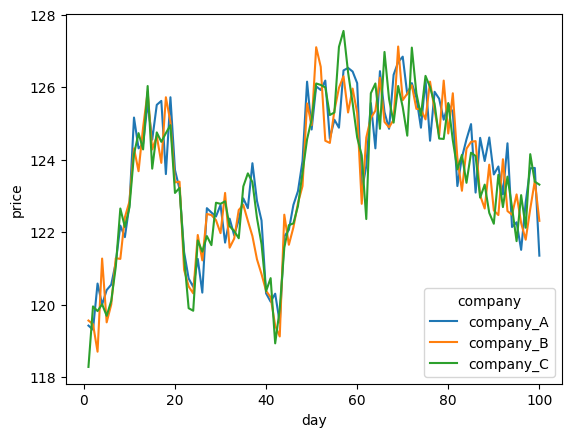

In [25]:
stock_prices = pd.read_csv("data/stock_prices.csv")
stock_prices.head()

stock_prices_long = stock_prices.melt(id_vars="day", var_name="company", value_name="price")
stock_prices_long.head()

sns.lineplot(data=stock_prices_long, x='day', y= 'price', hue='company')

---

## 3. Scatter Plots

**Scatter plots** are used to inspect the relationship between 2 numerical variables.  These are used frequently in descriptive analysis (e.g. for linear regression) but also in time series analysis to inspect autocorrelation (although this is not something considered in this course).  They can be produced in `matplotlib` using the function `plt.scatter` and using broadly similar syntax as `plt.lineplot`.  For time we will focus on the `seaborn` syntax in this section and leave those who are interested to read further.

For this section, download the `scatter_plot_data.csv` file from Canvas and load the data using the chunk below:

In [26]:
# Load scatter plot data
scatter_plot_data = pd.read_csv("data/scatter_plot_data.csv")
scatter_plot_data.head()

,x,y,cluster
0,-4.256226,-0.634580,A
1,-5.331987,-1.529541,A
2,-3.899639,-1.290443,A
3,-3.747548,-1.305390,A
4,-6.060828,-1.956672,A


The data is in long format by default and contains `x` and `y` variables, with a third variable called `cluster`.  To produce a scatter plot of `x` against `y` for cluster `A` we first filter the data for this cluster and then call the `sns.scatterplot` function:

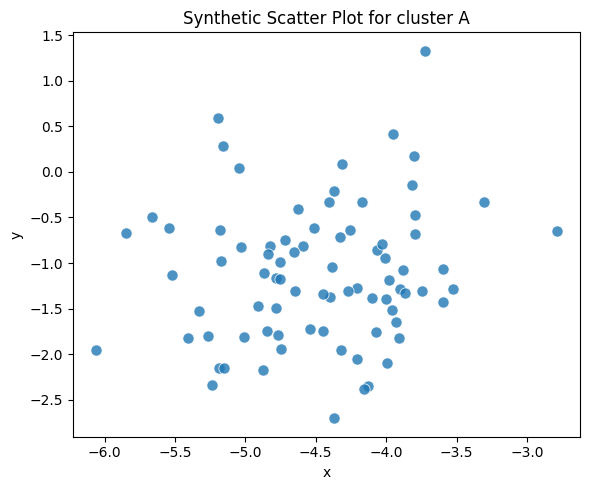

In [27]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=scatter_plot_data[scatter_plot_data["cluster"] == "A"],  # filter out Cluster 3 for better visibility
    x="x",
    y="y",
    alpha=0.8,
    s=65,
)
plt.title("Synthetic Scatter Plot for cluster A")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

We can easily extend this plot to include all three groupings by using a similar syntax as in the previous section:

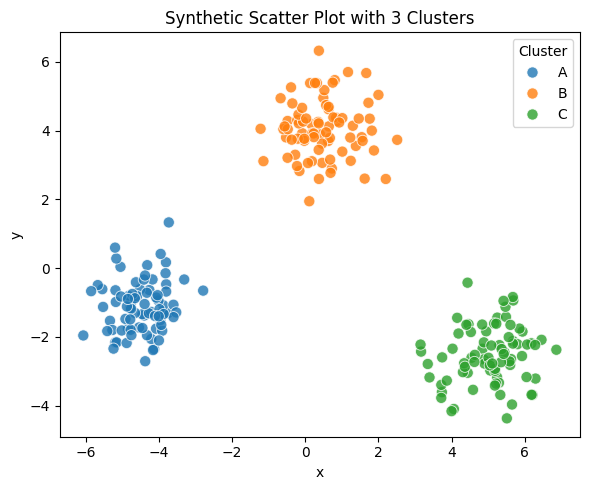

In [28]:
fig = plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=scatter_plot_data,  # use the full dataset with all clusters
    x="x",
    y="y",
    hue="cluster",          # color points by cluster
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],  # custom colors for clusters
    alpha=0.8,
    s=65
)
plt.title("Synthetic Scatter Plot with 3 Clusters")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()  

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3 Scatter Plot with `seaborn`

Use the following chunk to load the iris data set:

In [29]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["cluster"] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


1. Relabel the columns to fascilitate analysis.
2. Produce a scatter plot of sepal length against sepal width where points are different colors for different clusters.

___

**Solution:**

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

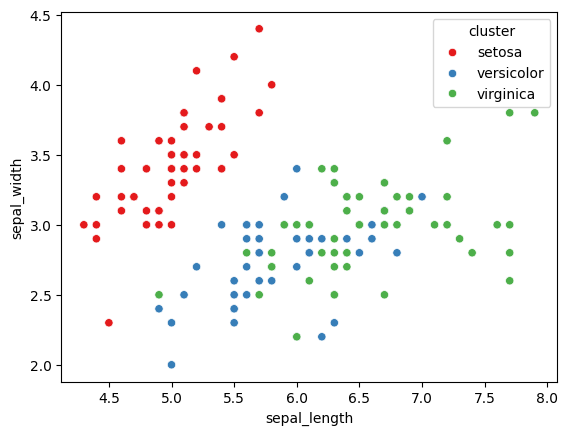

In [32]:
iris_df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'pedal_width', 'cluster']
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='cluster', palette='Set1')

---

## 4. Further Reading

This is starting to become more complicated than you are expected to learn for this course.  For those who are interested, if instead we wanted to plot all three clusters on the same plot but with different point colors we could instead use `sns.relplot()` function:

<Figure size 1200x500 with 0 Axes>

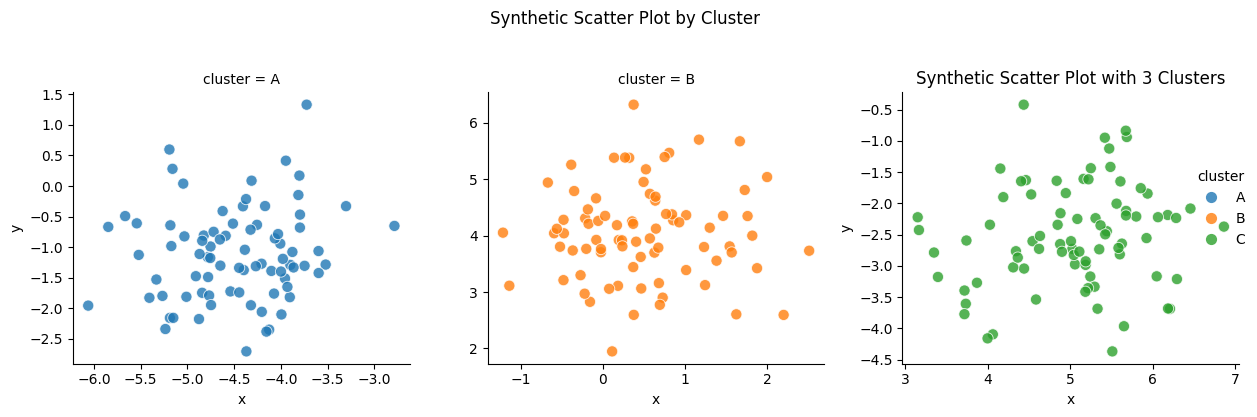

In [33]:
fig = plt.figure(figsize=(12, 5))
g = sns.relplot(
    data=scatter_plot_data,                 # full dataset
    x="x",                                  # x-axis variable
    y="y",                                  # y-axis variable
    hue="cluster",                          # color by cluster
    col="cluster",                          # one subplot per cluster
    col_order=["A", "B", "C"],              # optional fixed order
    kind="scatter",                         # scatter plot
    facet_kws={"sharex": False, "sharey": False},
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],
    alpha=0.8,
    s=65,
    height=4,                               # subplot height
    aspect=1                                # width/height ratio
)

g.set_axis_labels("x", "y")
g.fig.suptitle("Synthetic Scatter Plot by Cluster", y=1.03)
plt.title("Synthetic Scatter Plot with 3 Clusters")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

There are a vast collection of resources online for those who are interested in further reading into plotting in `python`. 

---

## Submission Checklist

- Ensure you have completed all problems in the notebook.
- Clear your document code outputs and rerun the notebook, checking for any new errors.
- At the top of your notebook click more options -> export -> pdf.
- Make sure your pdf has all code chunks clearly visible and executed.
- Submit before the posted deadline. 